In [1]:
import pandas as pd

df1 = pd.read_csv("air_quality_daily.csv")
df2 = pd.read_csv("master_daily.csv")
df3 = pd.read_csv("weather_daily.csv")

df1['date'] = pd.to_datetime(df1['date'])
df2['date'] = pd.to_datetime(df2['date'])
df3['date'] = pd.to_datetime(df3['date'])

final_df = df1.copy()
new_cols_df2 = [col for col in df2.columns if col not in final_df.columns or col == 'date']
df2_filtered = df2[new_cols_df2]
final_df = pd.merge(final_df, df2_filtered, on='date', how='inner')
new_cols_df3 = [col for col in df3.columns if col not in final_df.columns or col == 'date']
df3_filtered = df3[new_cols_df3]
final_df = pd.merge(final_df, df3_filtered, on='date', how='inner')
final_df = final_df.sort_values(by='date').reset_index(drop=True)
final_df.to_csv("final_unique_columns_dataset.csv", index=False)

print("Final dataset created successfully!")
print("Columns:", final_df.columns)
print("Shape:", final_df.shape)

/opt/conda/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.0' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/conda/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.4.0' currently installed).
  from pandas.core import (


Final dataset created successfully!
Columns: Index(['date', 'pm10_avg', 'pm25_avg', 'aqi', 'aqi_category', 'aqi_source',
       'temp_max', 'temp_min', 'temp_mean', 'wind_speed_max',
       'wind_speed_mean', 'humidity_mean', 'precipitation',
       'air_pollution_Delhi', 'N95_mask', 'air_purifier', 'breathing_problem',
       'AQI_Delhi', 'year', 'month', 'season'],
      dtype='str')
Shape: (2233, 21)


In [2]:
final_df.head()

,date,pm10_avg,pm25_avg,aqi,aqi_category,aqi_source,temp_max,temp_min,temp_mean,wind_speed_max,...,humidity_mean,precipitation,air_pollution_Delhi,N95_mask,air_purifier,breathing_problem,AQI_Delhi,year,month,season
0,2016-01-29,267.583333,356.0,443.0,Severe,openaq_computed,25.50,13.75,19.37,8.40,...,72.75,0.5,0.0,NaN,0,NaN,0.0,2016,1,Winter
1,2016-01-30,267.583333,203.0,364.0,Very Poor,openaq_computed,22.15,12.85,17.37,14.01,...,77.33,0.0,0.0,NaN,0,NaN,0.0,2016,1,Winter
2,2016-01-31,267.583333,124.0,304.0,Very Poor,openaq_computed,22.10,9.70,15.16,12.50,...,64.97,0.0,0.0,NaN,0,NaN,0.0,2016,1,Winter
3,2016-02-01,245.000000,136.0,313.0,Very Poor,openaq_computed,20.95,7.45,14.20,15.35,...,58.05,0.0,0.0,NaN,67,NaN,0.0,2016,2,Winter
4,2016-02-02,245.000000,148.0,322.0,Very Poor,openaq_computed,21.55,8.35,14.47,20.62,...,53.28,0.0,0.0,NaN,0,NaN,0.0,2016,2,Winter


In [3]:
nan_count = final_df.isna().sum()
nan_columns = nan_count[nan_count > 0]
print("Columns with missing values:")
print(nan_columns)

Columns with missing values:
pm25_avg                 1
aqi                      1
aqi_category             1
air_pollution_Delhi    313
N95_mask               649
breathing_problem      999
AQI_Delhi              428
dtype: int64


In [5]:
# Fill small numeric NaNs with median
final_df['pm25_avg'] = final_df['pm25_avg'].fillna(final_df['pm25_avg'].median())
final_df['aqi'] = final_df['aqi'].fillna(final_df['aqi'].median())

# Fill small categorical/binned NaNs with mode
for col in ['aqi_category', 'pm10_avg', 'pm25_avg', 'precipitation']:
    final_df[col] = final_df[col].fillna(final_df[col].mode()[0])

# Fill large missing categorical columns with 'Unknown'
for col in ['air_pollution_Delhi', 'N95_mask', 'breathing_problem', 'AQI_Delhi']:
    final_df[col] = final_df[col].fillna('Unknown')

print(final_df.isna().sum())

date                   0
pm10_avg               0
pm25_avg               0
aqi                    0
aqi_category           0
aqi_source             0
temp_max               0
temp_min               0
temp_mean              0
wind_speed_max         0
wind_speed_mean        0
humidity_mean          0
precipitation          0
air_pollution_Delhi    0
N95_mask               0
air_purifier           0
breathing_problem      0
AQI_Delhi              0
year                   0
month                  0
season                 0
dtype: int64


Accuracy: 0.9485

Classification Report:
              precision    recall  f1-score   support

        Good       0.96      0.98      0.97        51
    Moderate       0.99      0.96      0.98        82
        Poor       1.00      1.00      1.00        55
Satisfactory       1.00      1.00      1.00       118
      Severe       0.82      0.33      0.47        27
   Very Poor       0.86      0.99      0.92       114

    accuracy                           0.95       447
   macro avg       0.94      0.88      0.89       447
weighted avg       0.95      0.95      0.94       447



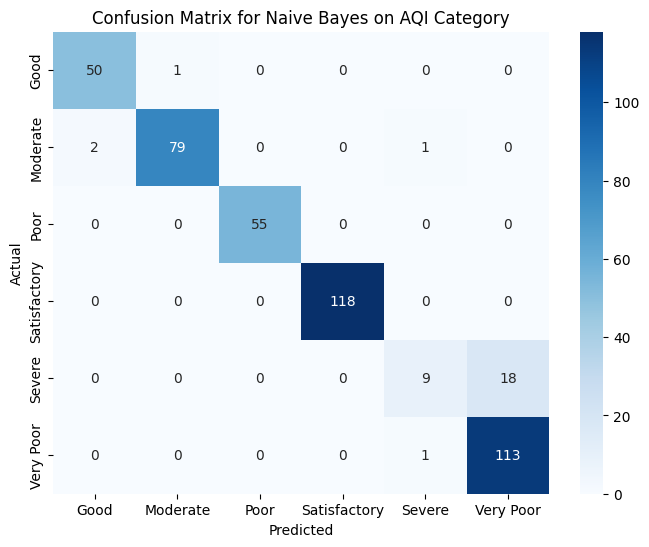

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Convert date column to datetime
final_df['date'] = pd.to_datetime(final_df['date'])

final_df['pm10_bin'] = pd.cut(final_df['pm10_avg'], bins=[0,50,100,150,200,500],
                              labels=['PM10_Low','PM10_Med','PM10_High','PM10_VHigh','PM10_Severe'])
final_df['pm25_bin'] = pd.cut(final_df['pm25_avg'], bins=[0,30,60,90,120,500],
                              labels=['PM25_Low','PM25_Med','PM25_High','PM25_VHigh','PM25_Severe'])
final_df['temp_bin'] = pd.cut(final_df['temp_mean'], bins=[-10,20,30,50],
                              labels=['Temp_Low','Temp_Med','Temp_High'])
final_df['wind_bin'] = pd.cut(final_df['wind_speed_mean'], bins=[0,5,10,50],
                              labels=['Wind_Low','Wind_Med','Wind_High'])
final_df['humidity_bin'] = pd.cut(final_df['humidity_mean'], bins=[0,30,60,100],
                                  labels=['Hum_Low','Hum_Med','Hum_High'])
final_df['precip_bin'] = pd.cut(final_df['precipitation'], bins=[-1,0,5,20,100],
                                labels=['Rain_None','Rain_Light','Rain_Med','Rain_Heavy'])


feature_cols = ['pm10_bin','pm25_bin','temp_bin','wind_bin','humidity_bin','precip_bin','season']
target_col = 'aqi_category'

X = final_df[feature_cols]
y = final_df[target_col]

for col in feature_cols:
    X[col] = pd.Categorical(X[col])
    if 'Unknown' not in X[col].cat.categories:
        X[col] = X[col].cat.add_categories('Unknown')
    X[col] = X[col].fillna('Unknown')
y = y.fillna('Unknown')

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train = X_train_raw.copy()
X_test = X_test_raw.copy()

for col in feature_cols:
    X_train[col] = pd.Categorical(X_train[col], categories=X_train[col].unique())
    X_test[col] = pd.Categorical(X_test[col], categories=X_train[col].cat.categories)

X_train_encoded = X_train.apply(lambda col: col.cat.codes)
X_test_encoded = X_test.apply(lambda col: col.cat.codes)

X_test_encoded = X_test_encoded.replace(-1, 0)

nb_model = CategoricalNB()
nb_model.fit(X_train_encoded, y_train)

y_pred = nb_model.predict(X_test_encoded)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=nb_model.classes_)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=nb_model.classes_,
            yticklabels=nb_model.classes_, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Naive Bayes on AQI Category")
plt.show()

Accuracy: 0.9553

Classification Report:
              precision    recall  f1-score   support

        Good       1.00      1.00      1.00        51
    Moderate       1.00      1.00      1.00        82
        Poor       1.00      1.00      1.00        55
Satisfactory       1.00      1.00      1.00       118
      Severe       0.71      0.44      0.55        27
   Very Poor       0.88      0.96      0.92       114

    accuracy                           0.96       447
   macro avg       0.93      0.90      0.91       447
weighted avg       0.95      0.96      0.95       447



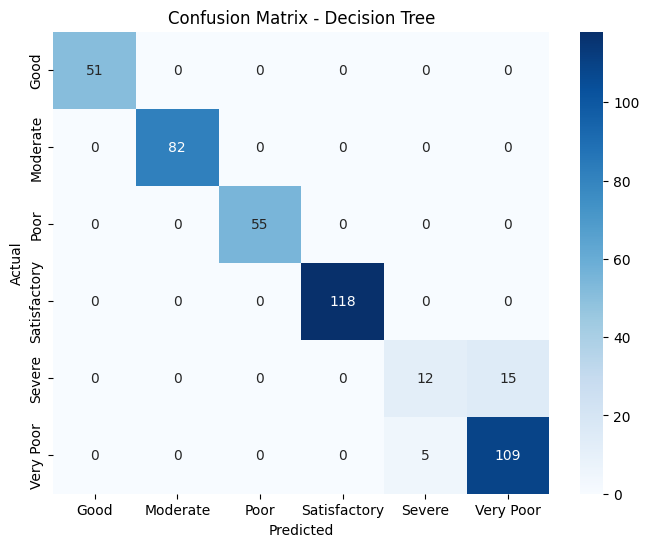

ROC-AUC (macro, OvR): 0.9820


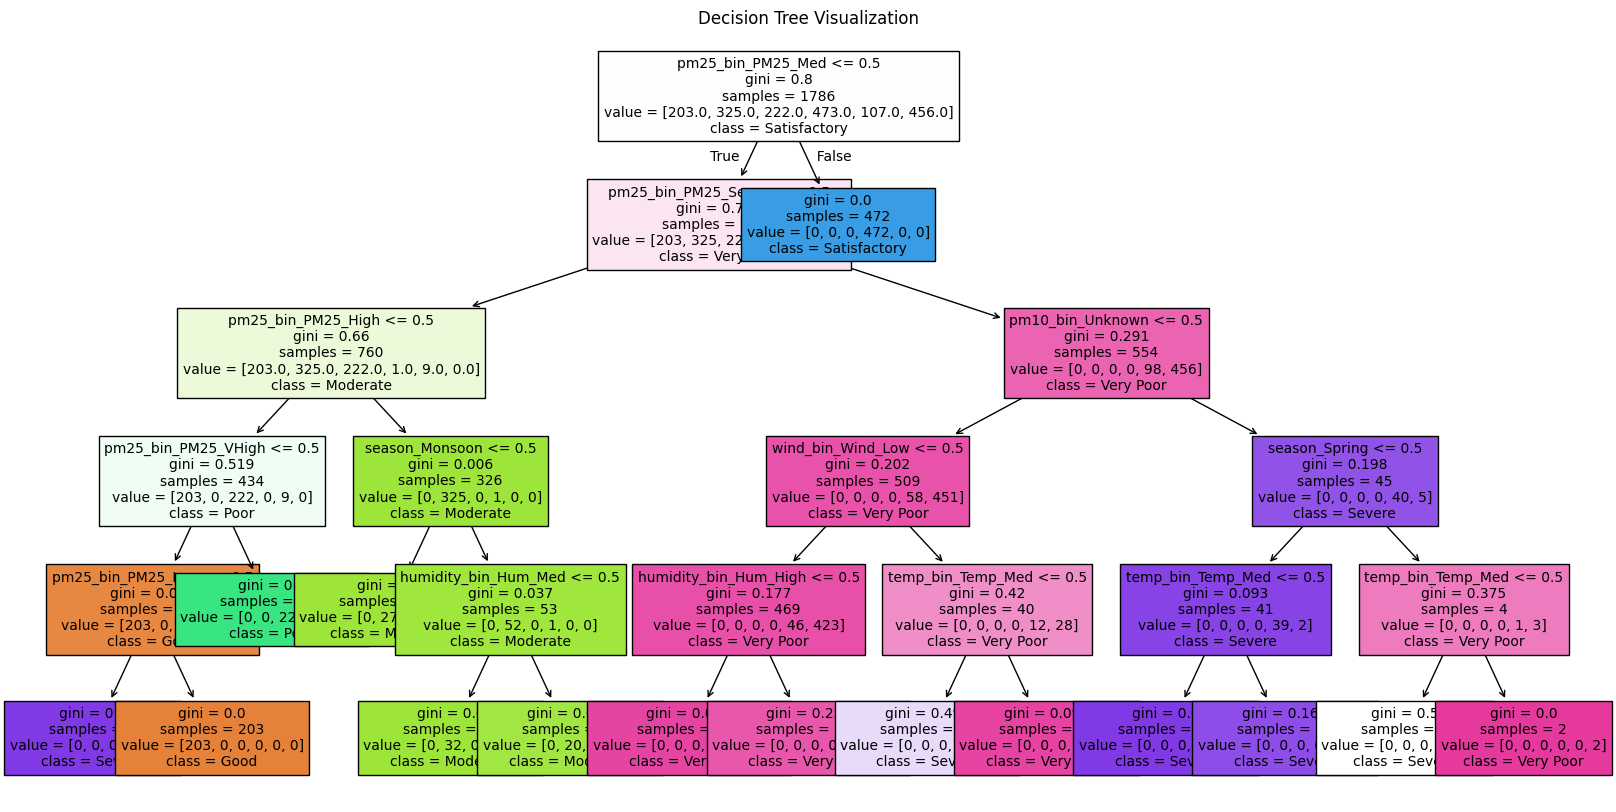

In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelBinarizer
import matplotlib.pyplot as plt
import seaborn as sns

feature_cols = ['pm10_bin','pm25_bin','temp_bin','wind_bin','humidity_bin','precip_bin','season']
target_col = 'aqi_category'

X = final_df[feature_cols].copy()
y = final_df[target_col].copy()

for col in feature_cols:
    X[col] = pd.Categorical(X[col])
    if 'Unknown' not in X[col].cat.categories:
        X[col] = X[col].cat.add_categories('Unknown')
    X[col] = X[col].fillna('Unknown')
y = y.fillna('Unknown')

X_encoded = pd.get_dummies(X)
y_encoded = y.astype('category').cat.codes
classes = y.astype('category').cat.categories

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)  # max_depth optional to prevent overfitting
dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_test)
y_proba = dt_model.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=classes))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)
roc_auc = roc_auc_score(y_test_bin, y_proba, average='macro', multi_class='ovr')
print(f"ROC-AUC (macro, OvR): {roc_auc:.4f}")

plt.figure(figsize=(20,10))
plot_tree(dt_model, feature_names=X_encoded.columns, class_names=classes, filled=True, fontsize=10)
plt.title("Decision Tree Visualization")
plt.show()

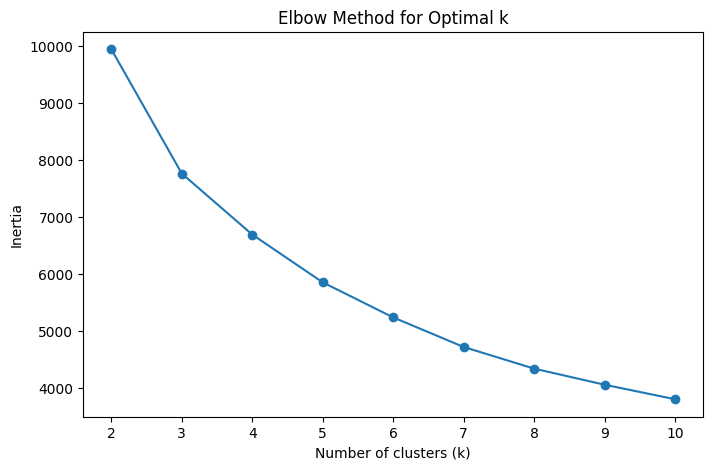

Silhouette Score: 0.2880


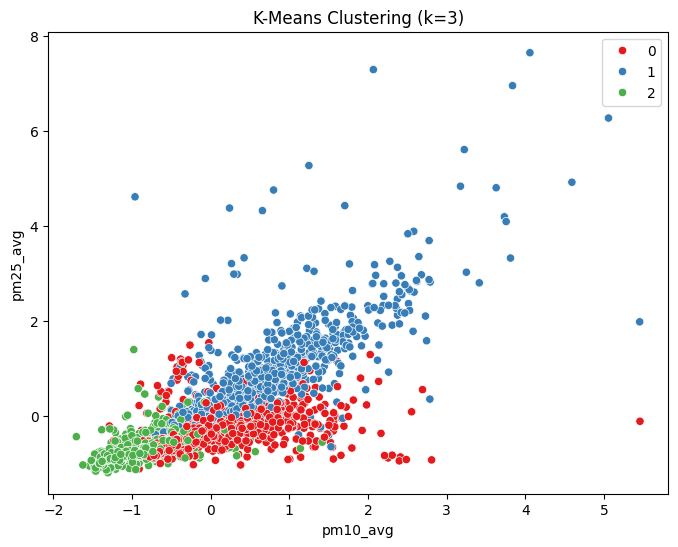

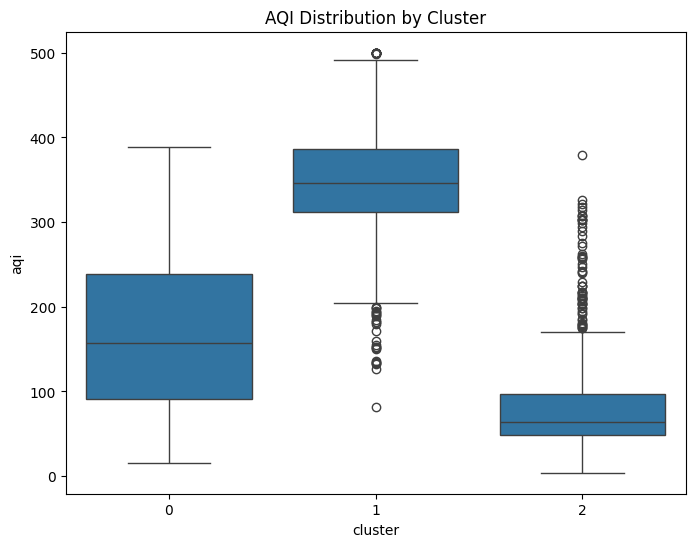

In [18]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

feature_cols = ['pm10_avg','pm25_avg','temp_mean','wind_speed_mean','humidity_mean','precipitation']

X = final_df[feature_cols]
X = X.fillna(X.median())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

k = 3
kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_labels = kmeans_model.fit_predict(X_scaled)

final_df['cluster'] = cluster_labels
sil_score = silhouette_score(X_scaled, cluster_labels)
print(f"Silhouette Score: {sil_score:.4f}")

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_scaled[:,0], 
    y=X_scaled[:,1], 
    hue=cluster_labels, 
    palette='Set1',
    legend='full'
)
plt.xlabel(feature_cols[0])
plt.ylabel(feature_cols[1])
plt.title(f"K-Means Clustering (k={k})")
plt.show()

plt.figure(figsize=(8,6))
sns.boxplot(x='cluster', y='aqi', data=final_df)
plt.title("AQI Distribution by Cluster")
plt.show()

Not enough clusters for evaluation metrics.


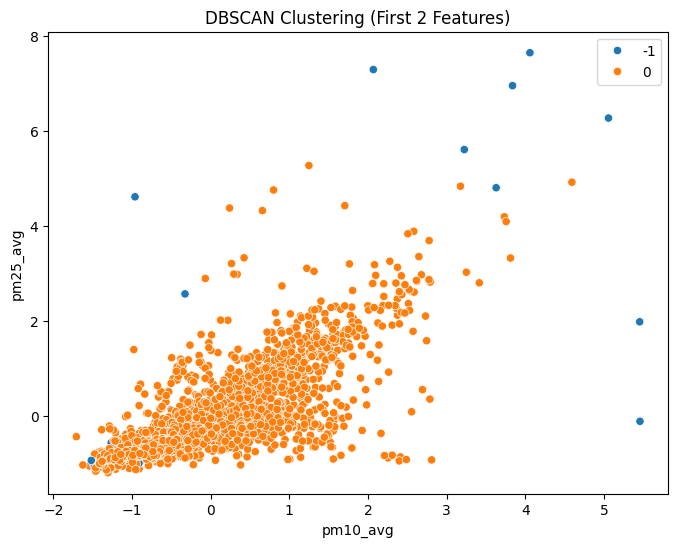

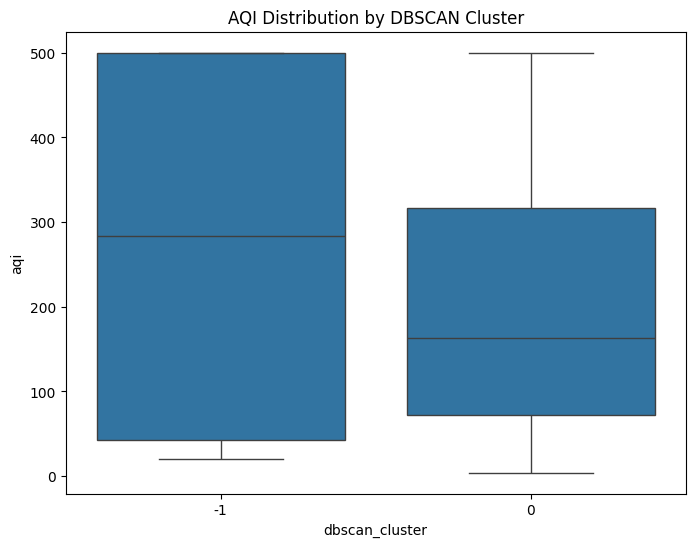

In [27]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns

feature_cols = ['pm10_avg','pm25_avg','temp_mean','wind_speed_mean','humidity_mean','precipitation']
X = final_df[feature_cols].copy()

X = X.fillna(X.median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

dbscan_model = DBSCAN(eps=1.5, min_samples=5)  
cluster_labels = dbscan_model.fit_predict(X_scaled)

final_df['dbscan_cluster'] = cluster_labels

mask = cluster_labels != -1
if len(np.unique(cluster_labels[mask])) > 1:
    sil_score = silhouette_score(X_scaled[mask], cluster_labels[mask])
    db_index = davies_bouldin_score(X_scaled[mask], cluster_labels[mask])
    print(f"Silhouette Score (ignoring noise): {sil_score:.4f}")
    print(f"Davies-Bouldin Index (ignoring noise): {db_index:.4f}")
else:
    print("Not enough clusters for evaluation metrics.")

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_scaled[:,0],
    y=X_scaled[:,1],
    hue=cluster_labels,
    palette='tab10',
    legend='full'
)
plt.xlabel(feature_cols[0])
plt.ylabel(feature_cols[1])
plt.title("DBSCAN Clustering (First 2 Features)")
plt.show()

plt.figure(figsize=(8,6))
sns.boxplot(x='dbscan_cluster', y='aqi', data=final_df)
plt.title("AQI Distribution by DBSCAN Cluster")
plt.show()

R² Score: 0.8764
RMSE: 46.1147
MAE: 32.9926


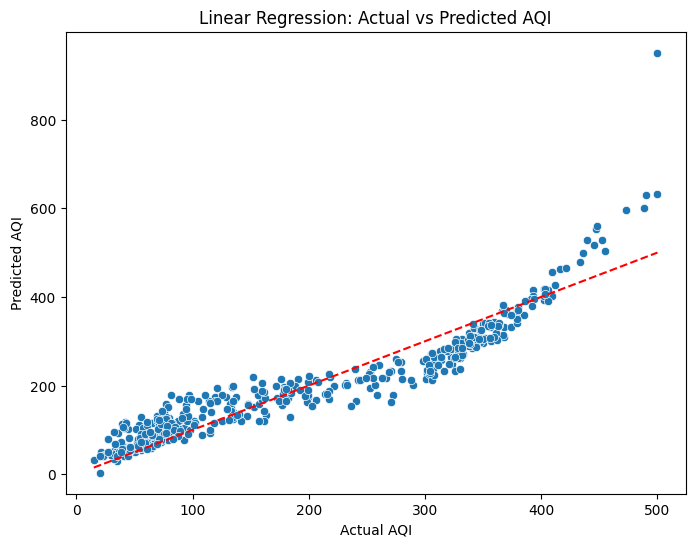

/tmp/ipykernel_927/753118411.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')


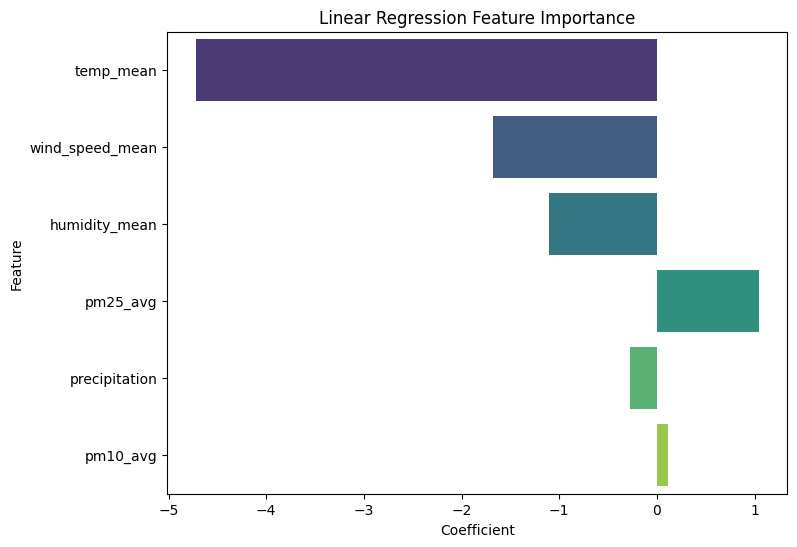

In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

feature_cols = ['pm10_avg','pm25_avg','temp_mean','wind_speed_mean','humidity_mean','precipitation']
target_col = 'aqi'  

X = final_df[feature_cols]
y = final_df[target_col]

X = X.fillna(X.median())
y = y.fillna(y.median())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal line
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Linear Regression: Actual vs Predicted AQI")
plt.show()

coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')
plt.title("Linear Regression Feature Importance")
plt.show()

Top 10 Association Rules:

                                            antecedents  \
38                  frozenset({aqi_category_Very Poor})   
981   frozenset({humidity_bin_Hum_High, temp_bin_Tem...   
2730  frozenset({pm10_bin_PM10_Severe, precip_bin_Ra...   
1019  frozenset({pm25_bin_PM25_Med, temp_bin_Temp_Me...   
1020  frozenset({temp_bin_Temp_Med, season_Monsoon, ...   
1021  frozenset({pm25_bin_PM25_Med, season_Monsoon, ...   
1011  frozenset({humidity_bin_Hum_High, temp_bin_Tem...   
1017  frozenset({pm25_bin_PM25_Med, temp_bin_Temp_Me...   
1018  frozenset({aqi_category_Satisfactory, temp_bin...   
1009  frozenset({humidity_bin_Hum_High, pm25_bin_PM2...   

                                 consequents   support  confidence      lift  
38         frozenset({pm25_bin_PM25_Severe})  0.255262         1.0  3.217579  
981           frozenset({aqi_category_Good})  0.084639         1.0  8.791339  
2730       frozenset({pm25_bin_PM25_Severe})  0.054635         1.0  3.217579  
1019  f

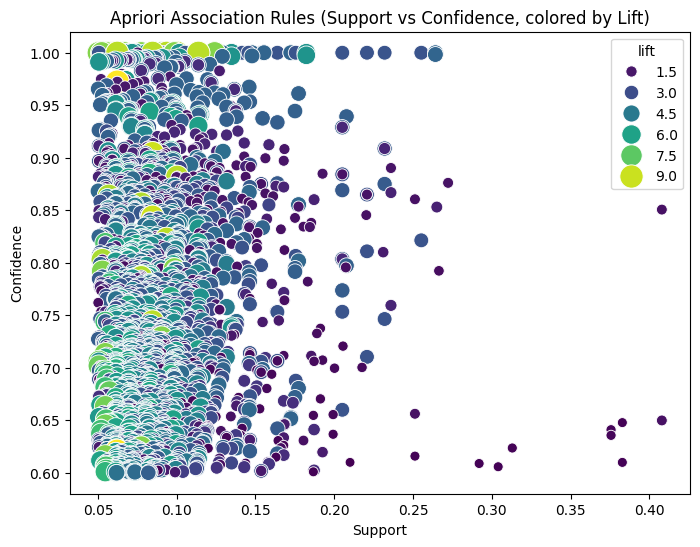

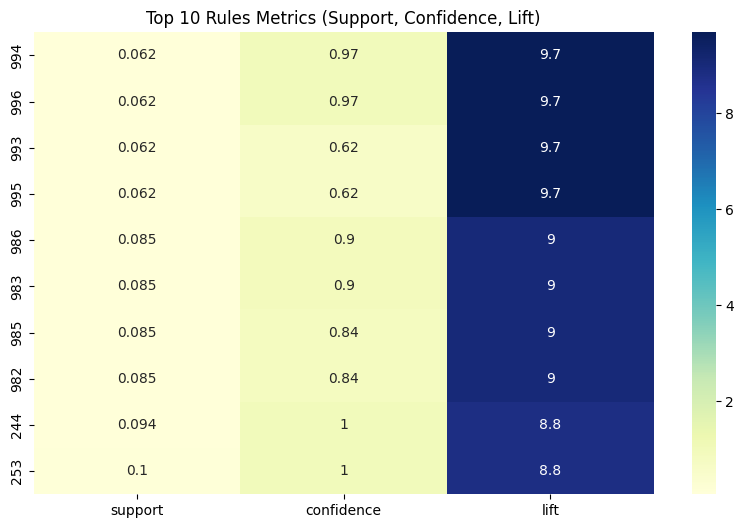

In [23]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt
import seaborn as sns

feature_cols = ['pm10_bin','pm25_bin','temp_bin','wind_bin','humidity_bin','precip_bin','season','aqi_category']
pattern_df = final_df[feature_cols].copy()

for col in feature_cols:
    pattern_df[col] = pd.Categorical(pattern_df[col])
    if 'Unknown' not in pattern_df[col].cat.categories:
        pattern_df[col] = pattern_df[col].cat.add_categories('Unknown')
    pattern_df[col] = pattern_df[col].fillna('Unknown')

pattern_df_encoded = pd.get_dummies(pattern_df)
frequent_itemsets = apriori(pattern_df_encoded, min_support=0.05, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6)
rules = rules.sort_values(by='confidence', ascending=False)
print("Top 10 Association Rules:\n")
print(rules[['antecedents','consequents','support','confidence','lift']].head(10))

plt.figure(figsize=(8,6))
sns.scatterplot(x='support', y='confidence', size='lift', hue='lift',
                sizes=(50, 300), palette='viridis', data=rules)
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Apriori Association Rules (Support vs Confidence, colored by Lift)")
plt.show()

top_rules = rules.sort_values(by='lift', ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.heatmap(top_rules[['support','confidence','lift']], annot=True, cmap='YlGnBu')
plt.title("Top 10 Rules Metrics (Support, Confidence, Lift)")
plt.show()